# Combining tools with LLMs

## Pipelines

input(pdf) -> implement RAG -> user input prompt -> LLM(assistant) rephrase for better RAG search -> use 

In [1]:
from langchain_groq import ChatGroq
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from typing import List, TypedDict, Literal

import data_transformation
from langchain_chroma import Chroma


In [2]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [3]:
class AgentState(TypedDict):
    user_input: str # The user's question
    retreived_vectors: List[str] = None # Retrieved docs 
    LLM2_decision: str="" # "yes" or "no" (from Grader)
    LLM3_answer: str="" # Final answer for this specific question
    counter: int = 0 # Loop counter to prevent infinite loops
    LLM1_rephrased: str="" # after passing through LLM1

    messages: List


### Create Node

In [4]:

# only implemented once, for embeding and indexing
def implement_RAG(path: str) -> None:

    documents = data_transformation.data_transform(path)

    DB_PATH = "./chroma_db_data"
    Chroma.from_documents(documents=documents, embedding=data_transformation.embed_model, persist_directory=DB_PATH )
    

In [5]:
def LLM1_rephrase(state: AgentState) -> None:
    
    state["counter"]+=1
    
    system_prompt = f"""
    You are an expert Technical Search Query Optimizer. 
    Your goal is to convert a conversational user question into a precise, 
    keyword-heavy search query for a Vector Database. Follow these rules: 
    1. Remove "fluff" words (e.g., "please", "can you tell me", "I want to know"). 
    2. Expand technical acronyms if context is clear (e.g., "ICE" -> "Internal Combustion Engine"). 
    3. Fix potential typos in technical terms. 
    4. Focus on nouns and specific engineering concepts. 
    5. Output ONLY the new query string. No preamble.

    The question is:

    {state["user_input"]}
    """

    state["LLM1_rephrased"] = llm.invoke(system_prompt).content

In [6]:
def RAG_search(state: AgentState) -> None:
    state["retreived_vectors"].clear()
    retreive = Chroma(persist_directory="chroma_db_data", embedding_function=data_transformation.embed_model)
    retriever = retreive.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
    )
    # This method lives inside the 'retriever' variable you just made
    retrieved_docs = retriever.invoke(state["LLM1_rephrased"])

    for i in retrieved_docs:
        state["retreived_vectors"].append(i.page_content)

In [7]:
def LLM2_decision(state: AgentState) -> None:
    system_prompt = f"""
    You are a grader assessing relevance of a retrieved document to a user question. 
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. 
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.

    question:
    {state["user_input"]}

    retreived context:
    {"\n".join(state["retreived_vectors"])}
    """ 

    state["LLM2_decision"] = llm.invoke(system_prompt).content


In [8]:
def LLM3_answer(state: AgentState) -> None:
    prompt = f"""
    You are an expert Engineering Research Assistant. 
    Your task is to answer the user's question based strictly on the provided Context.
    
    STRICT GUIDELINES:
    1. **Evidence-Based:** You must answer ONLY using the information in the Context. Do not use outside knowledge.
    2. **Citations:** Every claim you make must include a citation in brackets, e.g. [Source: file.pdf | Page: 12].
    3. **Tone:** Be professional, direct, and technical. Avoid conversational filler (e.g., "I hope this helps").
    4. **Structure:** Use Bullet Points, **Bold Text** for key terms, and clearly separated sections.
    5. **Math/Code:** If the context contains equations or code, format them properly (LaTeX for math).
    6. **Honesty:** If the context does not contain the answer, explicitly state: "The provided documents do not contain information about [topic]." Do not make things up.

    CONTEXT:
    {state["retreived_vectors"]}
    
    USER QUESTION: 
    {state["user_input"]}
    
    Provide your detailed engineering answer below:
    """


    state["LLM3_answer"] = llm.invoke(prompt).content

In [9]:
def decision(state: AgentState) -> Literal["yes", "no"]:

    if state["counter"]>3 or state["LLM2_decision"] == "yes":
        return "yes"
    return "no"

In [10]:
def pdf_input() -> str:
    return input("Enter pdf path: ")

In [11]:
def user_prompt() -> str:
    return input("Hi there, ask me something...")

### Build Graph

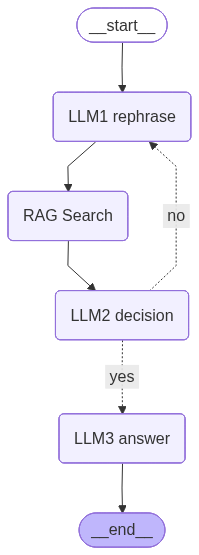

In [12]:
from IPython.display import Image, display

builder = StateGraph(AgentState)

builder.add_node("LLM1 rephrase", LLM1_rephrase)
builder.add_node("RAG Search", RAG_search)
builder.add_node("LLM2 decision", LLM2_decision)
builder.add_node("LLM3 answer", LLM3_answer)

builder.add_edge(START, "LLM1 rephrase")
builder.add_edge("LLM1 rephrase", "RAG Search")
builder.add_edge("RAG Search", "LLM2 decision")
builder.add_conditional_edges("LLM2 decision",
                              decision,
                              {
                                  "yes":"LLM3 answer",
                                  "no":"LLM1 rephrase"
                              })
builder.add_edge("LLM3 answer", END)

memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


Everything is done:

1. the user enters a pdf
2. implement RAG
3. while True
    1. User prompts a message
    2. the prompt enters the graph, and graph return a response
    3. repeat until user exit the session

4. END

hi there, i want to know in part 5.1 what does the variables of incertitude actually mean, like in real life and give an analogy please.

In [13]:
if __name__ == "__main__":
    path = pdf_input()
    implement_RAG(path) # creates ChromaDB folder with embeded vectors

    while True:
        prompt = user_prompt()
        if(prompt == "q"): break
        result = graph.invoke({
            "messages":[{"role":"user", "content":prompt}],
            "user_input":prompt,
            "retreived_vectors": [], # Retrieved docs 
            "LLM2_decision":"", # "yes" or "no" (from Grader)
            "LLM3_answer": "", # Final answer for this specific question
            "counter": 0, # Loop counter to prevent infinite loops
            "LLM1_rephrased": "" # after passing through LLM1
                                },config={"configurable":{"thread_id":1234}})    
        print(result["messages"][-1])

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT